# Time-To-Drain (TTD) Analysis

This notebook analyzes TTD metrics from Nuberu simulation experiments.

**TTD Definition**: Time from `stop_time` until the last request finishes processing.
This measures how long the system takes to drain all pending requests after new arrivals stop.

## Setup

In [80]:
# Install required dependencies (run once if needed)
%pip install pandas matplotlib seaborn pyarrow -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

# Path to metrics directory
METRICS_DIR = Path("../metrics")

## 1. Load TTD Data

In [82]:
# Load all TTD parquet files
ttd_global = pd.read_parquet(METRICS_DIR / "ttd_summary.parquet")
ttd_by_app = pd.read_parquet(METRICS_DIR / "ttd_by_app.parquet")
ttd_by_container = pd.read_parquet(METRICS_DIR / "ttd_by_container.parquet")

print(f"Global TTD: {len(ttd_global)} experiments")
print(f"TTD by App: {len(ttd_by_app)} rows")
print(f"TTD by Container: {len(ttd_by_container)} rows")
print("\nAvailable experiments:")
print(ttd_global["experiment"].unique())

Global TTD: 16 experiments
TTD by App: 32 rows
TTD by Container: 2016 rows

Available experiments:
['poisson_drain_simple_q0' 'poisson_drain_simple_q1000'
 'poisson_drain_smoothWRR_q0' 'poisson_drain_smoothWRR_q1000'
 'poisson_hard_simple_q0' 'poisson_hard_simple_q1000'
 'poisson_hard_smoothWRR_q0' 'poisson_hard_smoothWRR_q1000'
 'trace_drain_simple_q0' 'trace_drain_simple_q1000'
 'trace_drain_smoothWRR_q0' 'trace_drain_smoothWRR_q1000'
 'trace_hard_simple_q0' 'trace_hard_simple_q1000'
 'trace_hard_smoothWRR_q0' 'trace_hard_smoothWRR_q1000']


## 2. Experiment Selector

**Customize which experiments to analyze by modifying the lists below:**

In [83]:
# ============================================================================
# EXPERIMENT SELECTOR - Modify these lists to choose which experiments to analyze
# ============================================================================

# Option 1: Select specific experiments by name
SELECTED_EXPERIMENTS = [
    "poisson_drain_simple_q1000",
    "poisson_drain_smoothWRR_q1000",
    "poisson_hard_simple_q1000",
    "poisson_hard_smoothWRR_q1000",
    # Uncomment to add more:
    # 'poisson_drain_simple_q0',
    # 'poisson_drain_smoothWRR_q0',
    # 'poisson_hard_simple_q0',
    # 'poisson_hard_smoothWRR_q0',
    # 'trace_drain_simple_q0',
    # 'trace_hard_simple_q0',
]

# Option 2: Use filters instead
# Uncomment one of these to use filter-based selection:
# SELECTED_EXPERIMENTS = ttd_global[ttd_global['distribution'] == 'poisson']['experiment'].tolist()
# SELECTED_EXPERIMENTS = ttd_global[ttd_global['termination'] == 'drain']['experiment'].tolist()
# SELECTED_EXPERIMENTS = ttd_global[ttd_global['queue_size'] == 1000]['experiment'].tolist()
SELECTED_EXPERIMENTS = ttd_global["experiment"].unique().tolist()  # ALL experiments

print(f"Selected {len(SELECTED_EXPERIMENTS)} experiments for analysis:")
for exp in SELECTED_EXPERIMENTS:
    print(f"  - {exp}")

Selected 16 experiments for analysis:
  - poisson_drain_simple_q0
  - poisson_drain_simple_q1000
  - poisson_drain_smoothWRR_q0
  - poisson_drain_smoothWRR_q1000
  - poisson_hard_simple_q0
  - poisson_hard_simple_q1000
  - poisson_hard_smoothWRR_q0
  - poisson_hard_smoothWRR_q1000
  - trace_drain_simple_q0
  - trace_drain_simple_q1000
  - trace_drain_smoothWRR_q0
  - trace_drain_smoothWRR_q1000
  - trace_hard_simple_q0
  - trace_hard_simple_q1000
  - trace_hard_smoothWRR_q0
  - trace_hard_smoothWRR_q1000


In [84]:
# Filter data based on selection
df = ttd_global[ttd_global["experiment"].isin(SELECTED_EXPERIMENTS)].copy()
app_df = ttd_by_app[ttd_by_app["experiment"].isin(SELECTED_EXPERIMENTS)].copy()
cont_df = ttd_by_container[
    ttd_by_container["experiment"].isin(SELECTED_EXPERIMENTS)
].copy()

# Add readable load_balancer names
df["load_balancer"] = df["LB"].replace(
    {"simple": "Round Robin", "smoothWRR": "Smooth WRR"}
)
app_df["load_balancer"] = app_df["LB"].replace(
    {"simple": "Round Robin", "smoothWRR": "Smooth WRR"}
)
cont_df["load_balancer"] = cont_df["LB"].replace(
    {"simple": "Round Robin", "smoothWRR": "Smooth WRR"}
)

print("\nFiltered data:")
print(f"  Global: {len(df)} experiments")
print(f"  By App: {len(app_df)} rows")
print(f"  By Container: {len(cont_df)} rows")


Filtered data:
  Global: 16 experiments
  By App: 32 rows
  By Container: 2016 rows


## 3. Global TTD Comparison

Compare TTD across load balancers (RR vs SWRR) and termination modes (drain vs hard).

In [85]:
# Display summary table
summary = df[
    [
        "termination",
        "load_balancer",
        "queue_size",
        "ttd",
        "drained_count",
        "completed_count",
        "rejected_count",
    ]
]
summary = summary.sort_values("ttd", ascending=False)
print("\nTTD Global Comparison")
print("=" * 80)
display(summary)


TTD Global Comparison


,termination,load_balancer,queue_size,ttd,drained_count,completed_count,rejected_count
9,drain,Round Robin,1000,32.400000,154,4743,0
1,drain,Round Robin,1000,24.452648,134,4127,0
8,drain,Round Robin,0,1.905769,122,4258,485
0,drain,Round Robin,0,1.890658,108,3779,348
11,drain,Smooth WRR,1000,1.133824,142,4743,0
2,drain,Smooth WRR,0,0.962414,110,3748,379
3,drain,Smooth WRR,1000,0.962414,112,4127,0
10,drain,Smooth WRR,0,0.262571,34,3043,1700
4,hard,Round Robin,0,0.000000,0,3671,348
5,hard,Round Robin,1000,0.000000,0,3993,0


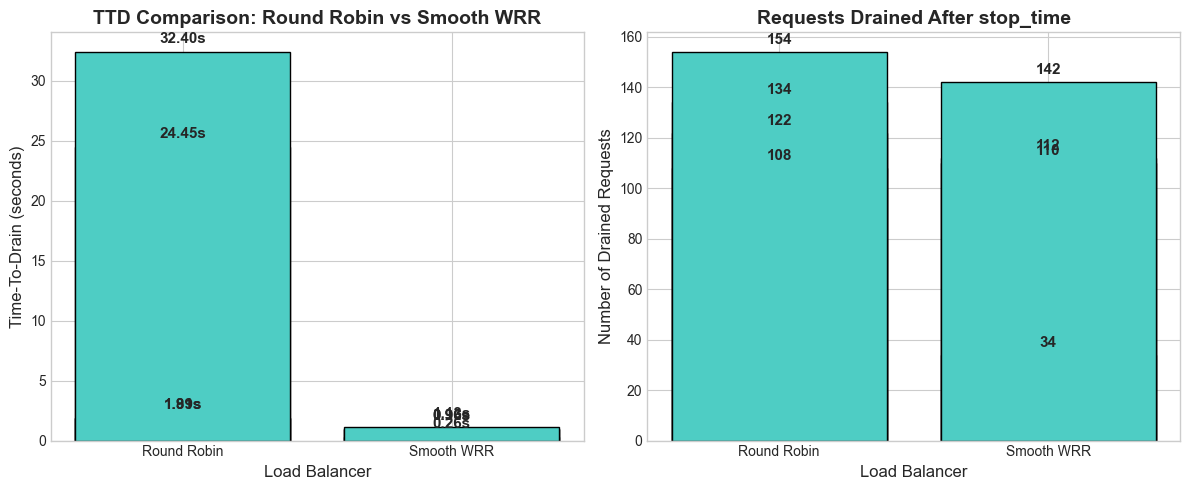


SWRR reduces TTD by 49.1% compared to Round Robin


In [86]:
# Visualize TTD by load_balancer (drain mode only)
drain_df = df[df["termination"] == "drain"]

if len(drain_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # TTD bar chart
    ax1 = axes[0]
    colors = ["#FF6B6B", "#4ECDC4"]
    bars = ax1.bar(
        drain_df["load_balancer"],
        drain_df["ttd"],
        color=colors[: len(drain_df)],
        edgecolor="black",
    )
    ax1.set_ylabel("Time-To-Drain (seconds)", fontsize=12)
    ax1.set_xlabel("Load Balancer", fontsize=12)
    ax1.set_title(
        "TTD Comparison: Round Robin vs Smooth WRR", fontsize=14, fontweight="bold"
    )

    # Add value labels
    for bar, val in zip(bars, drain_df["ttd"]):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.2f}s",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    # Drained count bar chart
    ax2 = axes[1]
    bars2 = ax2.bar(
        drain_df["load_balancer"],
        drain_df["drained_count"],
        color=colors[: len(drain_df)],
        edgecolor="black",
    )
    ax2.set_ylabel("Number of Drained Requests", fontsize=12)
    ax2.set_xlabel("Load Balancer", fontsize=12)
    ax2.set_title("Requests Drained After stop_time", fontsize=14, fontweight="bold")

    for bar, val in zip(bars2, drain_df["drained_count"]):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{val}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "ttd_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Calculate improvement if both load balancers present
    rr_data = drain_df[drain_df["load_balancer"] == "Round Robin"]
    swrr_data = drain_df[drain_df["load_balancer"] == "Smooth WRR"]
    if len(rr_data) > 0 and len(swrr_data) > 0:
        rr_ttd = rr_data["ttd"].values[0]
        swrr_ttd = swrr_data["ttd"].values[0]
        improvement = (1 - swrr_ttd / rr_ttd) * 100
        print(f"\nSWRR reduces TTD by {improvement:.1f}% compared to Round Robin")
else:
    print("No drain mode experiments in selection")

## 4. TTD by Application

Analyze which applications take longer to drain.

In [87]:
# Filter drain mode experiments
app_drain = app_df[app_df["termination"] == "drain"].copy()

if len(app_drain) > 0:
    print("\nTTD by Application (Drain Mode)")
    print("=" * 80)
    display(
        app_drain[
            [
                "load_balancer",
                "app",
                "queue_size",
                "ttd",
                "drained_count",
                "completed_count",
            ]
        ].sort_values(["load_balancer", "ttd"], ascending=[True, False])
    )
else:
    print("No drain mode experiments in selection")


TTD by Application (Drain Mode)


,load_balancer,app,queue_size,ttd,drained_count,completed_count
19,Round Robin,app1,1000,32.400000,147,3540
3,Round Robin,app1,1000,24.452648,123,3072
17,Round Robin,app1,0,1.905769,115,3055
1,Round Robin,app1,0,1.890658,99,2910
2,Round Robin,app0,1000,0.246369,11,1055
16,Round Robin,app0,0,0.188347,7,1203
18,Round Robin,app0,1000,0.188347,7,1203
0,Round Robin,app0,0,0.158663,9,869
23,Smooth WRR,app1,1000,1.133824,135,3540
5,Smooth WRR,app1,0,0.962414,101,2879


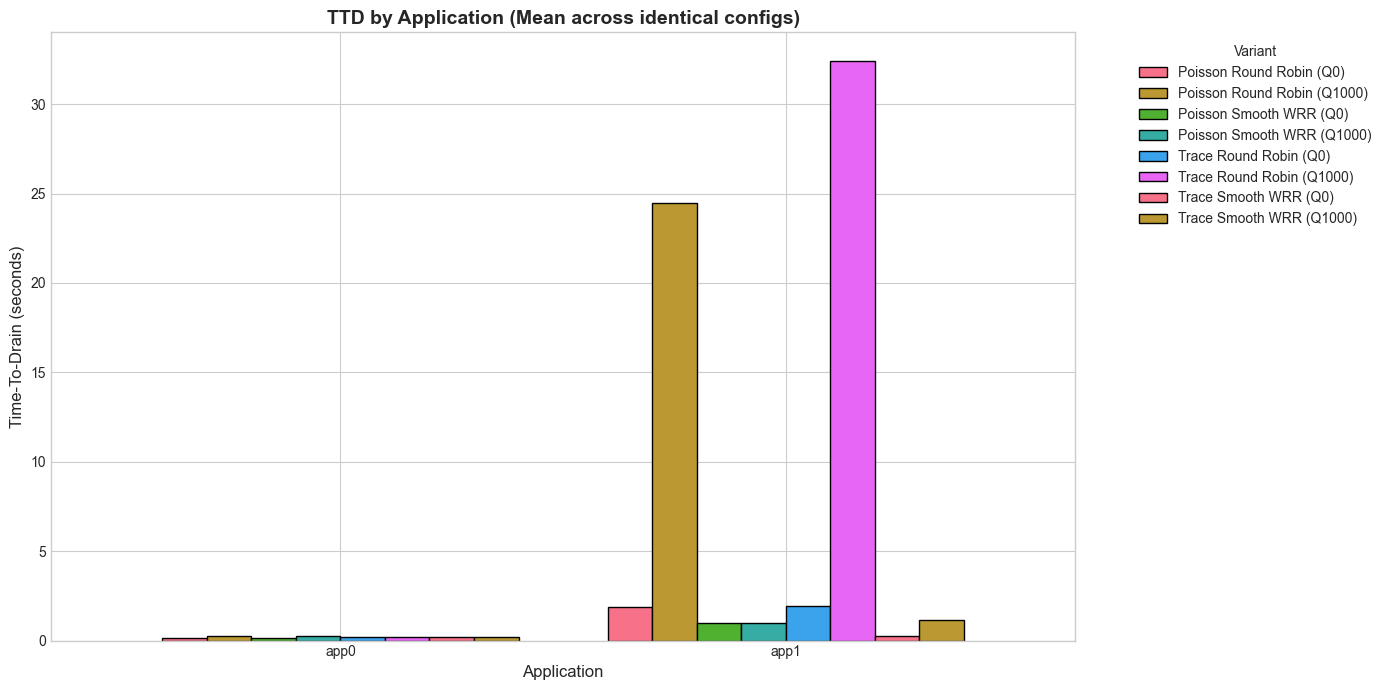

In [88]:
# Visualize TTD by app
if len(app_drain) > 0:
    # Merge helpful columns from the main df if they aren't present
    cols_to_merge = []
    for col in ["queue_size", "distribution"]:
        if col not in app_drain.columns:
            cols_to_merge.append(col)

    if cols_to_merge and "experiment" in app_drain.columns:
        # Get unique attributes per experiment from global df
        exp_attrs = df[["experiment"] + cols_to_merge].drop_duplicates()
        app_drain = app_drain.merge(exp_attrs, on="experiment", how="left")

    fig, ax = plt.subplots(figsize=(14, 7))

    # Create a descriptive variant label to avoid duplicates
    # We need to distinguish between workloads (Poisson vs Trace) if both are present
    def make_label(row):
        parts = [row["load_balancer"]]
        if "distribution" in row and pd.notna(row["distribution"]):
            parts.insert(0, row["distribution"].capitalize())
        if "queue_size" in row and pd.notna(row["queue_size"]):
            parts.append(f"(Q{int(row['queue_size'])})")
        return " ".join(parts)

    app_drain["variant"] = app_drain.apply(make_label, axis=1)

    # Now try to pivot. If duplicates still exist, pivot_table handles them by averaging.
    # pivot() raises ValueError on duplicates, pivot_table() aggregates.
    pivot = app_drain.pivot_table(
        index="app", columns="variant", values="ttd", aggfunc="mean"
    )

    pivot.plot(kind="bar", ax=ax, edgecolor="black", width=0.8)

    ax.set_ylabel("Time-To-Drain (seconds)", fontsize=12)
    ax.set_xlabel("Application", fontsize=12)
    ax.set_title(
        "TTD by Application (Mean across identical configs)",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(title="Variant", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig(METRICS_DIR / "ttd_by_app.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No drain mode experiments in selection")

## 5. TTD by Container

Identify containers that are bottlenecks (high TTD).

In [89]:
# Filter drain mode and get top containers by TTD
cont_drain = cont_df[cont_df["termination"] == "drain"].copy()

if len(cont_drain) > 0:
    print("\nTop 10 Containers by TTD (Drain Mode)")
    print("=" * 80)
    top_containers = cont_drain.nlargest(10, "ttd")
    display(
        top_containers[
            ["load_balancer", "container", "ttd", "drained_count", "completed_count"]
        ]
    )
else:
    print("No drain mode experiments in selection")


Top 10 Containers by TTD (Drain Mode)


,load_balancer,container,ttd,drained_count,completed_count
1223,Round Robin,c6i.2xlarge-7-cc0app1-1,32.400000,17,31
1222,Round Robin,c6i.2xlarge-7-cc0app1-0,32.391667,17,31
215,Round Robin,c6i.2xlarge-7-cc0app1-1,24.452648,13,27
214,Round Robin,c6i.2xlarge-7-cc0app1-0,24.451836,13,27
1097,Round Robin,c6i.2xlarge-7-cc0app1-1,1.905769,1,11
1096,Round Robin,c6i.2xlarge-7-cc0app1-0,1.897222,1,11
89,Round Robin,c6i.2xlarge-7-cc0app1-1,1.890658,1,14
88,Round Robin,c6i.2xlarge-7-cc0app1-0,1.879437,1,14
1433,Smooth WRR,c6i.2xlarge-20-cc1app1-3,1.133824,2,31
1432,Smooth WRR,c6i.2xlarge-20-cc1app1-2,1.125490,2,31


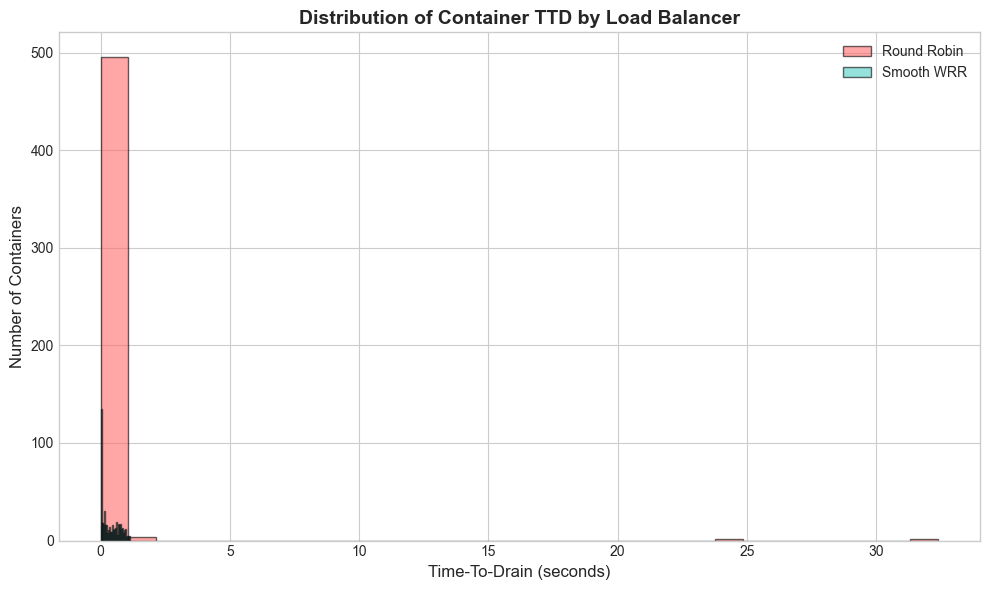

In [90]:
# TTD distribution by load_balancer
if len(cont_drain) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    for lb, color in [("Round Robin", "#FF6B6B"), ("Smooth WRR", "#4ECDC4")]:
        data = cont_drain[cont_drain["load_balancer"] == lb]["ttd"]
        if len(data) > 0:
            ax.hist(data, bins=30, alpha=0.6, label=lb, color=color, edgecolor="black")

    ax.set_xlabel("Time-To-Drain (seconds)", fontsize=12)
    ax.set_ylabel("Number of Containers", fontsize=12)
    ax.set_title(
        "Distribution of Container TTD by Load Balancer", fontsize=14, fontweight="bold"
    )
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        METRICS_DIR / "ttd_container_distribution.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

## 6. Summary Statistics

In [91]:
# Summary by load_balancer
if len(cont_drain) > 0:
    print("\nContainer TTD Statistics by Load Balancer (Drain Mode)")
    print("=" * 80)

    stats = cont_drain.groupby("load_balancer")["ttd"].agg(
        ["mean", "std", "min", "max", "median"]
    )
    stats.columns = ["Mean", "Std Dev", "Min", "Max", "Median"]
    display(stats.round(4))


Container TTD Statistics by Load Balancer (Drain Mode)


,Mean,Std Dev,Min,Max,Median
load_balancer,,,,,
Round Robin,0.6609,2.5316,0.0,32.4000,0.4265
Smooth WRR,0.3688,0.3411,0.0,1.1338,0.2743


## 7. Key Findings

### TTD Comparison
- **Smooth Weighted Round Robin (SWRR)** significantly reduces Time-To-Drain compared to simple Round Robin
- SWRR achieves more balanced load distribution across containers
- The improvement is more pronounced for applications with higher processing times (app1)

### Bottleneck Analysis
- With Round Robin, specific containers accumulate pending requests while others are idle
- SWRR distributes load more evenly, preventing bottleneck formation
- Container-level TTD analysis helps identify infrastructure optimization opportunities